In [1]:
import os
import pandas as pd
import numpy as np
import pyranges as pr
import gseapy as gp
import matplotlib.pyplot as plt
import pyreadr
from pathlib import Path
from gseapy import dotplot
import warnings
warnings.filterwarnings('ignore')

In [2]:
# file paths
GENE_SETS_DIR = 'data/Gene_sets_db'
OUT_DIR       = Path('figures')

# GSEA parameters
MIN_GENE_SET_SIZE = 10
MAX_GENE_SET_SIZE = 500
PERMUTATION_NUM = 1000
SEED = 6
THREADS = 4
FDR_CUTOFF = 0.25



In [3]:
# Load Hallmark gene sets only
def csv_to_dict(df):
    result = {}
    for _, row in df.iterrows():
        if pd.notna(row[0]) and str(row[0]).strip():
            result[row[0]] = list(row[2:].dropna().astype(str))
    return result

hall_dict = csv_to_dict(
    pd.read_csv(os.path.join(GENE_SETS_DIR, 'MSigDB_Hallmark_2020.csv'), delimiter=';', header=None)
)
print(f'Hallmark gene sets: {len(hall_dict)}')

Hallmark gene sets: 50


In [4]:
# read in ranked list
df = pd.read_csv('data/log2FC_H3K4me3.tsv', sep='\t')

gsea_df = df[['gene', 'log2FC']].copy()

glist_rnk = (
    gsea_df
    .dropna(subset=['gene', 'log2FC'])
    .set_index('gene')
    .rename(columns={'log2FC': 'signed_score'})
    .sort_values('signed_score', ascending=False)
)


## 10) Run GSEA Prerank - Hallmark Only

In [5]:
%%time
pre_res = gp.prerank(
    rnk=glist_rnk,
    gene_sets=hall_dict,
    threads=THREADS,
    min_size=MIN_GENE_SET_SIZE,
    max_size=MAX_GENE_SET_SIZE,
    permutation_num=1000,
    outdir=str(OUT_DIR / 'gsea_hallmark_output'),
    seed=SEED,
    verbose=True
)

print('GSEA completed!')

2026-03-09 13:50:17,301 [INFO] Input gene rankings contains duplicated IDs
2026-03-09 13:50:17,309 [WARNING] Input gene rankings contains inf values!
2026-03-09 13:50:17,311 [WARNING] Duplicated values found in preranked stats: 0.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-09 13:50:17,312 [INFO] Parsing data files for GSEA.............................
2026-03-09 13:50:17,368 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=10
2026-03-09 13:50:17,370 [INFO] 0050 gene_sets used for further statistical testing.....
2026-03-09 13:50:17,371 [INFO] Start to run GSEA...Might take a while..................
2026-03-09 13:50:38,754 [INFO] Congratulations. GSEApy runs successfully................



GSEA completed!
CPU times: user 23.7 s, sys: 965 ms, total: 24.7 s
Wall time: 21.5 s


In [6]:
# Filter by FDR cutoff and sort
sig_df = pre_res.res2d[pre_res.res2d['FDR q-val'] < FDR_CUTOFF]
sig_df_sorted = sig_df.sort_values(by='FDR q-val', ascending=True)
sig_terms_number = len(sig_df_sorted)

print(f"Significant pathways (FDR < {FDR_CUTOFF}): {sig_terms_number}")
sig_df_sorted

Significant pathways (FDR < 0.25): 24


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
1,prerank,G2-M Checkpoint,-0.409372,-1.920264,0.0,0.001231,0.002,67/197,20.45%,PML;SUV39H1;LBR;SMC1A;TFDP1;DKC1;PURA;CUL3;CCN...
0,prerank,E2F Targets,-0.408963,-1.929684,0.0,0.002461,0.002,70/198,20.09%,SUV39H1;LBR;DSCC1;SMC1A;TFRC;HMGB2;RBBP7;CENPM...
3,prerank,Oxidative Phosphorylation,-0.358767,-1.684535,0.0,0.014153,0.045,77/199,25.82%,TIMM13;MPC1;ECHS1;ALAS1;MRPS15;POLR2F;ATP6V1H;...
2,prerank,DNA Repair,-0.378734,-1.705645,0.0,0.015589,0.037,55/148,25.05%,BCAP31;ERCC2;ADA;RFC4;POLR2F;TSG101;SEC61A1;GT...
4,prerank,Glycolysis,-0.333529,-1.567859,0.0,0.036674,0.142,70/198,25.32%,SDC2;ME1;VCAN;PHKA2;IDUA;GPC4;PKP2;IL13RA1;RAR...
6,prerank,Protein Secretion,-0.347,-1.452942,0.018036,0.077357,0.36,29/95,20.58%,RPS6KA3;ARFGAP3;ARFGEF1;TSG101;ATP6V1H;VAMP3;A...
8,prerank,Hedgehog Signaling,-0.426789,-1.435943,0.061386,0.079532,0.405,15/35,22.26%,PML;UNC5C;NKX6-1;L1CAM;CDK5R1;MYH9;RASA1;CRMP1...
9,prerank,heme Metabolism,-0.30243,-1.419566,0.007463,0.083002,0.452,73/196,22.87%,XK;ALDH1L1;ATG4A;CCDC28A;MARCHF2;TFRC;TSPAN5;B...
5,prerank,Fatty Acid Metabolism,-0.322884,-1.459264,0.011257,0.085327,0.343,55/155,23.74%,ME1;MAOA;SUCLG2;ECHS1;NCAPH2;LGALS1;ECI2;FH;SE...
11,prerank,Unfolded Protein Response,-0.328541,-1.402657,0.029354,0.087378,0.503,32/111,17.04%,CXXC1;EIF4G1;ATF4;SPCS3;EIF4A2;DKC1;XBP1;YWHAZ...


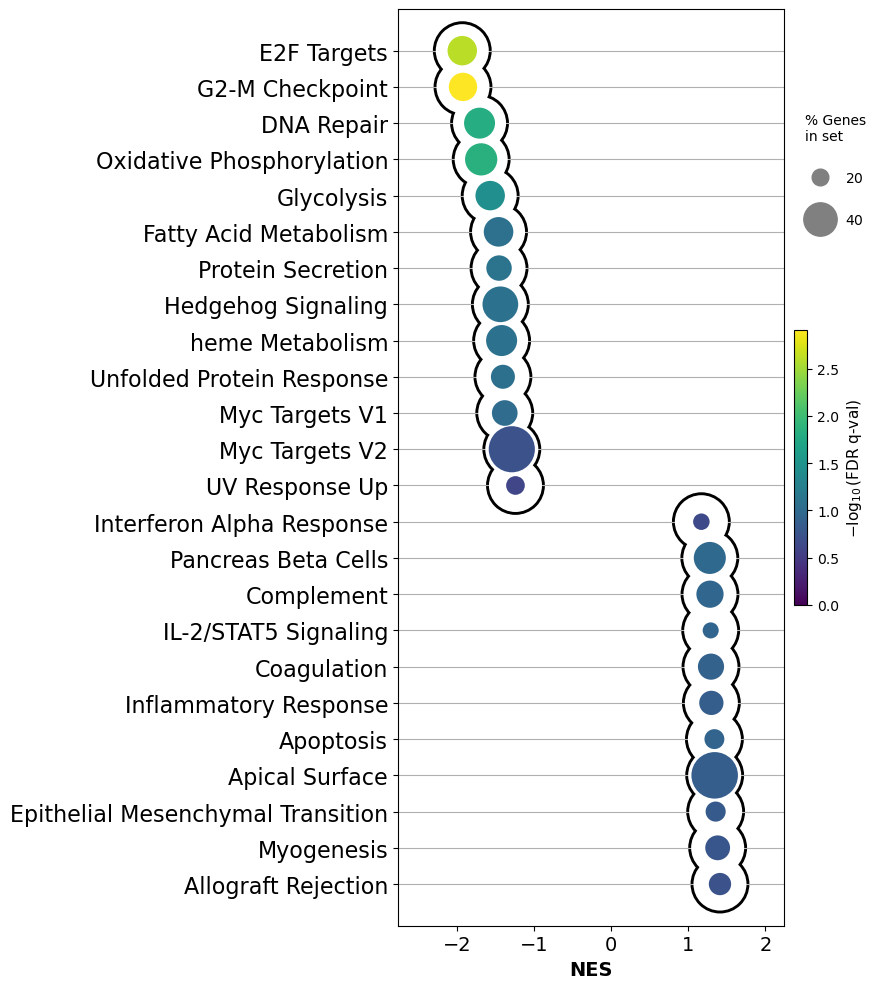

In [7]:
sorted_res = pre_res.res2d.sort_values('FDR q-val', ascending=True)

ax = dotplot(
    sorted_res,
    column='FDR q-val',
    cmap=plt.cm.viridis,
    size=10,
    top_term=sig_terms_number,
    figsize=(10, 10),
    show_ring=True,
    cutoff=1.0
)

fig = ax.figure

fdr_vals = sorted_res['FDR q-val'].astype(float)
neg_log_fdr = -np.log10(fdr_vals)
vmin, vmax = neg_log_fdr.min(), neg_log_fdr.max()

for collection in ax.collections:
    collection.set_clim(vmin, vmax)

axes_to_remove = [a for a in fig.axes if a != ax]
for a in axes_to_remove:
    a.remove()

sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, aspect=20, pad=0.02)
cbar.set_label(r'$-\log_{10}$(FDR q-val)', fontsize=11)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(
    OUT_DIR / 'H3K4me3_in_promoters_LOY_vs_ROY_dotplot.pdf',
    format='pdf',
    dpi=300,
   bbox_inches='tight'
)
plt.show()